In [ ]:
# Ауыл шаруашылығында суару қажеттілігін болжау жобасы

In [1]:
# pandas — кестелермен жұмыс істеу үшін
import pandas as pd

# numpy — математикалық операциялар үшін
import numpy as np

# графиктер салу үшін
import matplotlib.pyplot as plt
import seaborn as sns

# машиналық оқыту құралдары
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# CSV файлдан деректерді жүктейміз
df = pd.read_csv('data_core.csv')

# алғашқы 5 жолды көреміз
df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea


In [3]:
# деректер типі мен бос мәндерді тексеру
df.info()

# статистикалық мәліметтер
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temparature      8000 non-null   float64
 1   Humidity         8000 non-null   float64
 2   Moisture         8000 non-null   float64
 3   Soil Type        8000 non-null   object 
 4   Crop Type        8000 non-null   object 
 5   Nitrogen         8000 non-null   int64  
 6   Potassium        8000 non-null   int64  
 7   Phosphorous      8000 non-null   int64  
 8   Fertilizer Name  8000 non-null   object 
dtypes: float64(3), int64(3), object(3)
memory usage: 562.6+ KB


,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,30.338895,59.210731,43.580862,18.429125,3.916375,18.512500
std,4.478262,8.177366,12.596156,11.852406,5.494807,13.244113
min,20.000000,40.020000,20.000000,0.000000,0.000000,0.000000
25%,27.050000,53.277500,33.967500,9.000000,0.000000,8.000000
50%,30.240000,59.110000,42.250000,14.000000,1.000000,18.000000
75%,33.460000,65.082500,52.950000,26.000000,5.000000,30.000000
max,40.000000,80.000000,70.000000,46.000000,23.000000,46.000000


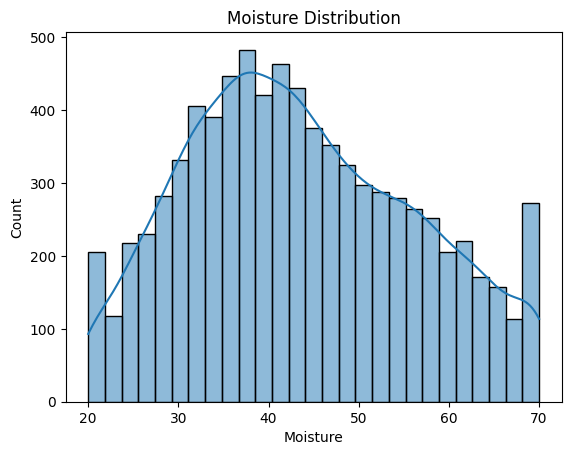

In [4]:
# Moisture (топырақ ылғалдылығы) таралуы
sns.histplot(df['Moisture'], kde=True)
plt.title("Moisture Distribution")
plt.show()

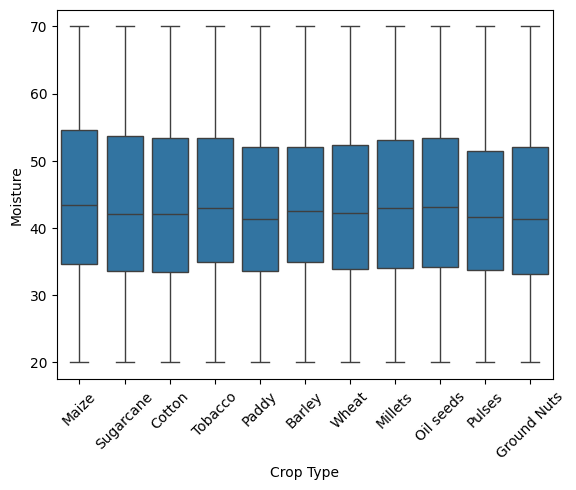

In [5]:
# Crop Type бойынша Moisture қалай өзгереді
sns.boxplot(x='Crop Type', y='Moisture', data=df)
plt.xticks(rotation=45)
plt.show()

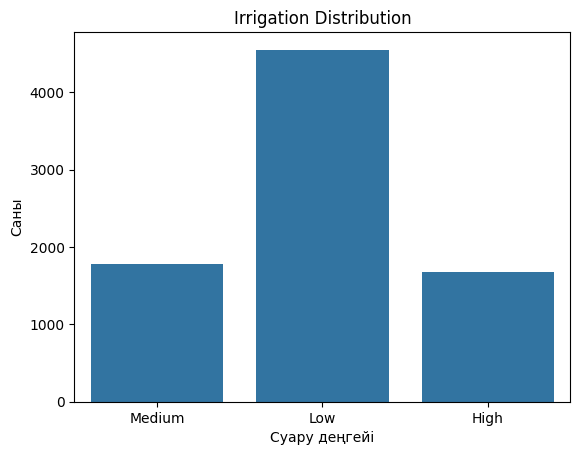

In [6]:
# суару қажеттілігін анықтайтын функция
def irrigation(row):
    
    # егер топырақ құрғақ болса
    if row['Moisture'] < 40:
        
        # температура жоғары болса
        if row['Temparature'] > 30:
            return 'High'   # көп су керек
        
        # ауа құрғақ болса
        elif row['Humidity'] < 50:
            return 'Medium'
        
        else:
            return 'Medium'
    
    else:
        return 'Low'  # су қажет емес

# жаңа баған жасаймыз
df['Irrigation_Need'] = df.apply(irrigation, axis=1)
# суару деңгейінің таралуы (Low / Medium / High)
sns.countplot(x='Irrigation_Need', data=df)

plt.title("Irrigation Distribution")     # графиктің атауы
plt.xlabel("Суару деңгейі")              # X ось
plt.ylabel("Саны")                       # Y ось

plt.show()

In [7]:
# әр класс қанша екенін көру
df['Irrigation_Need'].value_counts()

Irrigation_Need
Low       4549
Medium    1775
High      1676
Name: count, dtype: int64

In [8]:
# мәтінді санға айналдыру (ML үшін керек)
le = LabelEncoder()

df['target'] = le.fit_transform(df['Irrigation_Need'])

In [9]:
# Fertilizer бұл жобада қажет емес
df = df.drop(columns=['Fertilizer Name', 'Irrigation_Need'])

In [10]:
# X — белгілер (features)
X = df.drop('target', axis=1)

# y — мақсатты айнымалы (target)
y = df['target']

In [19]:
# мәтіндерді санға айналдыру (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)
X.head()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous,Soil Type_Clayey,Soil Type_Loamy,Soil Type_Red,Soil Type_Sandy,Crop Type_Cotton,Crop Type_Ground Nuts,Crop Type_Maize,Crop Type_Millets,Crop Type_Oil seeds,Crop Type_Paddy,Crop Type_Pulses,Crop Type_Sugarcane,Crop Type_Tobacco,Crop Type_Wheat
0,26.0,52.0,38.0,37,0,0,False,False,False,True,False,False,True,False,False,False,False,False,False,False
1,29.0,52.0,45.0,12,0,36,False,True,False,False,False,False,False,False,False,False,False,True,False,False
2,34.0,65.0,62.0,7,9,30,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,32.0,62.0,34.0,22,0,20,False,False,True,False,False,False,False,False,False,False,False,False,True,False
4,28.0,54.0,46.0,35,0,0,True,False,False,False,False,False,False,False,False,True,False,False,False,False


In [20]:
# деректерді 80% / 20% бөлу
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# деректер қалай бөлінгенін көру
print(X_train.shape, X_test.shape)

(6400, 20) (1600, 20)


In [13]:
# Random Forest моделін құрамыз
model = RandomForestClassifier(
    n_estimators=100,   # ағаштар саны
    random_state=42
)

# модельді үйретеміз
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
# тест деректерге болжау жасаймыз
y_pred = model.predict(X_test)
print(y_pred[:10])
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head()

[1 1 0 0 2 0 1 1 1 1]


,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,2,2


In [15]:
# модельдің сапасын көреміз
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       330
           1       1.00      1.00      1.00       900
           2       1.00      1.00      1.00       370

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



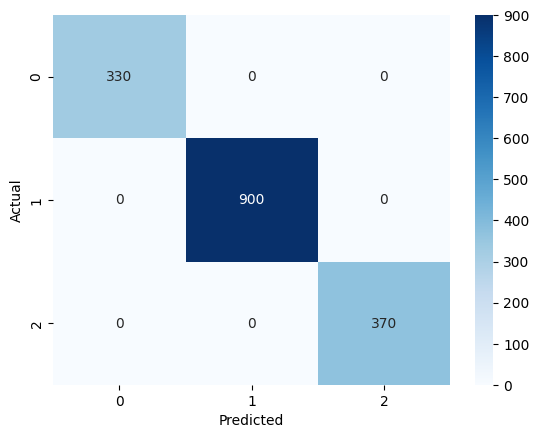

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

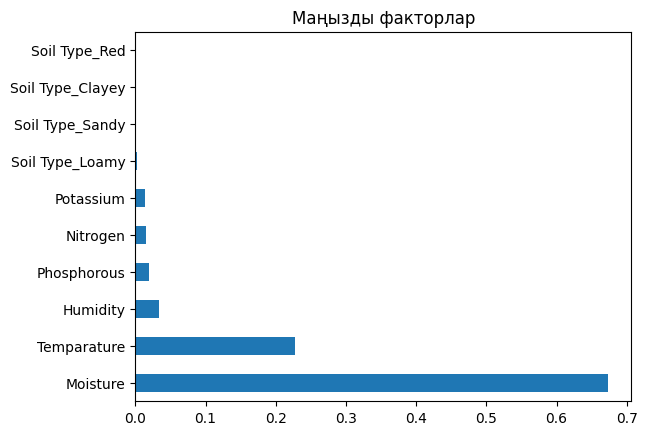

In [17]:
# қай фактор маңызды екенін көреміз
importances = model.feature_importances_

feat_importance = pd.Series(importances, index=X.columns)

feat_importance.nlargest(10).plot(kind='barh')
plt.title("Маңызды факторлар")
plt.show()


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\ofice\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


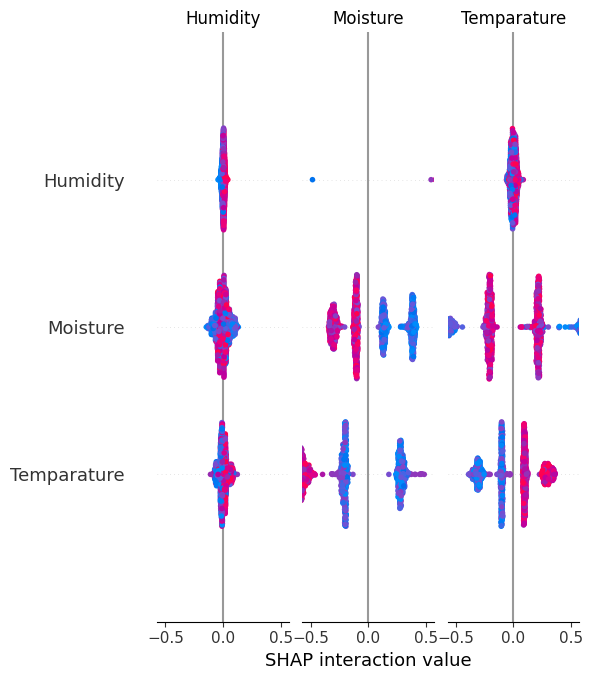

In [18]:
# SHAP кітапханасын орнату
!pip install shap

import shap

# модельді түсіндіру
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# график
shap.summary_plot(shap_values, X_test)